# AI Precision Oncology

# Notebook 02 – Clinical Survival Analysis

---

## Research Question

How does patient survival evolve over time in the METABRIC breast cancer cohort, and how do clinically important subgroups differ in their survival outcomes?

---

## Objectives

In this notebook we will:

- Understand survival analysis concepts.
- Learn why survival analysis differs from traditional machine learning.
- Build Kaplan–Meier survival curves.
- Compare survival between clinical groups.
- Perform Log-Rank hypothesis testing.
- Build Cox Proportional Hazard models.
- Interpret Hazard Ratios clinically.

---

## Dataset

METABRIC Breast Cancer Dataset

---

In [1]:
# ============================================================
# Survival Analysis Libraries
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter

plt.style.use("ggplot")

print("Survival analysis libraries imported successfully.")

Survival analysis libraries imported successfully.


In [2]:
# ============================================================
# Load Dataset
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET = PROJECT_ROOT / "datasets" / "Breast Cancer METABRIC.csv"

df = pd.read_csv(DATASET)

print("=" * 60)
print("Dataset Loaded")
print("=" * 60)

print(df.shape)

Dataset Loaded
(2509, 34)


In [3]:
# ============================================================
# Verify Survival Variables
# ============================================================

print("=" * 60)
print("Overall Survival Status")
print("=" * 60)

display(
    df["Overall Survival Status"]
    .value_counts(dropna=False)
)

print("\n")

print("=" * 60)
print("Overall Survival Months")
print("=" * 60)

display(
    df["Overall Survival (Months)"]
    .describe()
)

Overall Survival Status


Overall Survival Status
Deceased    1144
Living       837
NaN          528
Name: count, dtype: int64



Overall Survival Months


count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: Overall Survival (Months), dtype: float64

In [4]:
# ============================================================
# Prepare Survival Dataset
# ============================================================

survival_df = (
    df[
        [
            "Overall Survival (Months)",
            "Overall Survival Status"
        ]
    ]
    .dropna()
    .copy()
)

# Convert survival status to event indicator
survival_df["Event"] = (
    survival_df["Overall Survival Status"]
    .map({
        "Living": 0,
        "Deceased": 1
    })
)

print("=" * 60)
print("Prepared Survival Dataset")
print("=" * 60)

print(f"Rows : {survival_df.shape[0]}")
print(f"Columns : {survival_df.shape[1]}")

display(survival_df.head())

Prepared Survival Dataset
Rows : 1981
Columns : 3


,Overall Survival (Months),Overall Survival Status,Event
0,140.500000,Living,0
1,84.633333,Living,0
2,163.700000,Deceased,1
3,164.933333,Living,0
4,41.366667,Deceased,1


In [5]:
# ============================================================
# Validate Survival Dataset
# ============================================================

print("=" * 60)
print("Missing Values")
print("=" * 60)

print(survival_df.isnull().sum())

print("\n")

print("=" * 60)
print("Event Distribution")
print("=" * 60)

print(survival_df["Event"].value_counts())

Missing Values
Overall Survival (Months)    0
Overall Survival Status      0
Event                        0
dtype: int64


Event Distribution
Event
1    1144
0     837
Name: count, dtype: int64


In [6]:
# ============================================================
# Fit Kaplan-Meier Estimator
# ============================================================

kmf = KaplanMeierFitter()

kmf.fit(
    durations=survival_df["Overall Survival (Months)"],
    event_observed=survival_df["Event"],
    label="METABRIC Cohort"
)

print("Kaplan-Meier model fitted successfully.")

Kaplan-Meier model fitted successfully.


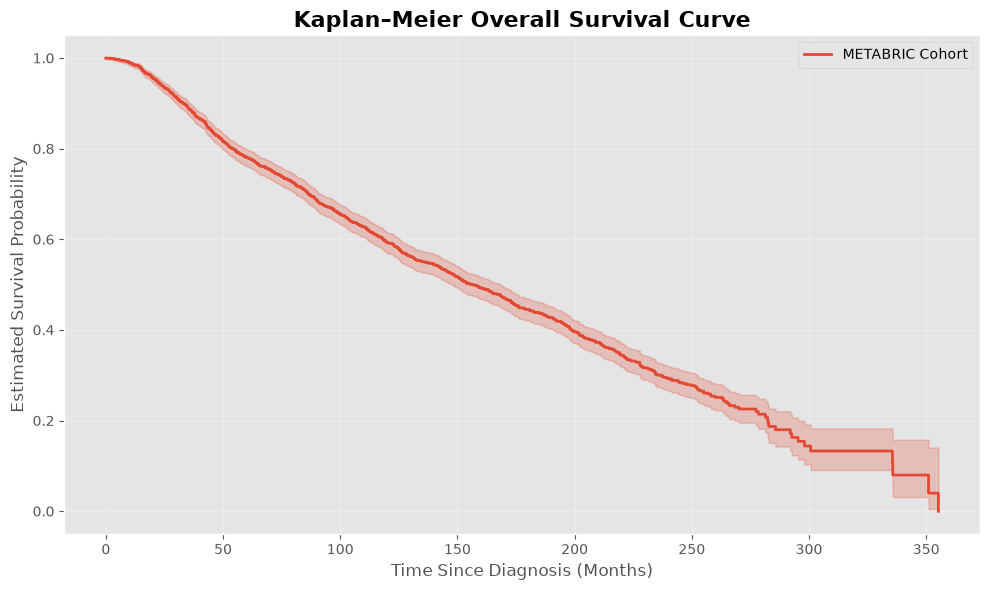

In [7]:
# ============================================================
# Kaplan–Meier Survival Curve
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,
    linewidth=2
)

ax.set_title(
    "Kaplan–Meier Overall Survival Curve",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Time Since Diagnosis (Months)")
ax.set_ylabel("Estimated Survival Probability")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "kaplan_meier_overall_survival.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# ============================================================
# Prepare ER Survival Dataset
# ============================================================

er_df = (
    df[
        [
            "Overall Survival (Months)",
            "Overall Survival Status",
            "ER Status"
        ]
    ]
    .dropna()
    .copy()
)

er_df["Event"] = (
    er_df["Overall Survival Status"]
    .map({
        "Living": 0,
        "Deceased": 1
    })
)

print(er_df.head())

print("\n")

print(er_df["ER Status"].value_counts())

   Overall Survival (Months) Overall Survival Status ER Status  Event
0                 140.500000                  Living  Positive      0
1                  84.633333                  Living  Positive      0
2                 163.700000                Deceased  Positive      1
3                 164.933333                  Living  Positive      0
4                  41.366667                Deceased  Positive      1


ER Status
Positive    1507
Negative     474
Name: count, dtype: int64


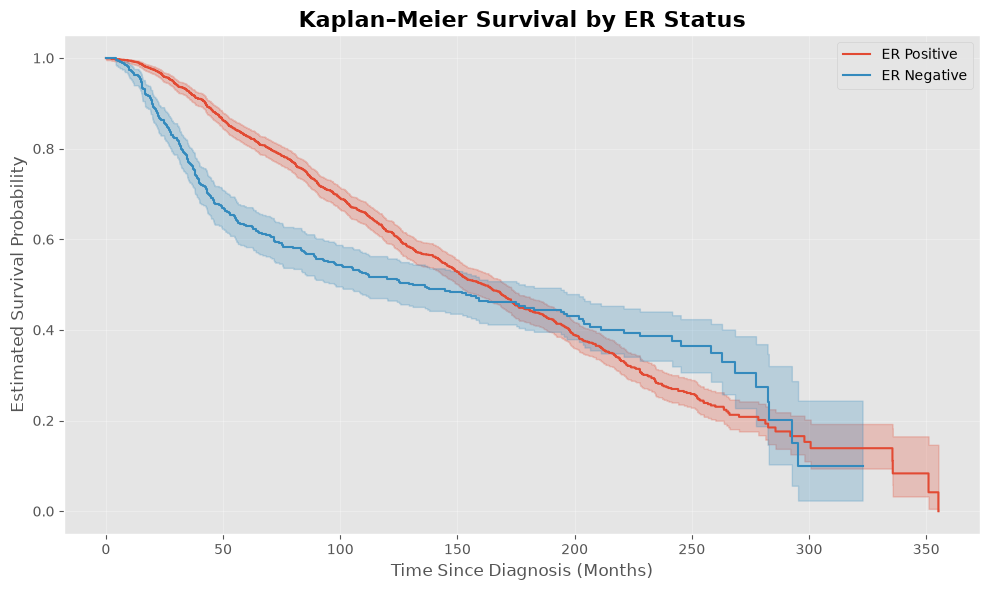

In [9]:
# ============================================================
# Kaplan-Meier by ER Status
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

kmf_positive = KaplanMeierFitter()
kmf_negative = KaplanMeierFitter()

positive = er_df["ER Status"] == "Positive"
negative = er_df["ER Status"] == "Negative"

kmf_positive.fit(
    durations=er_df.loc[positive, "Overall Survival (Months)"],
    event_observed=er_df.loc[positive, "Event"],
    label="ER Positive"
)

kmf_negative.fit(
    durations=er_df.loc[negative, "Overall Survival (Months)"],
    event_observed=er_df.loc[negative, "Event"],
    label="ER Negative"
)

kmf_positive.plot_survival_function(ax=ax, ci_show=True)
kmf_negative.plot_survival_function(ax=ax, ci_show=True)

ax.set_title(
    "Kaplan–Meier Survival by ER Status",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Time Since Diagnosis (Months)")
ax.set_ylabel("Estimated Survival Probability")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [10]:
# ============================================================
# Log-Rank Test: ER Positive vs ER Negative
# ============================================================

results = logrank_test(
    durations_A=er_df.loc[
        positive,
        "Overall Survival (Months)"
    ],
    durations_B=er_df.loc[
        negative,
        "Overall Survival (Months)"
    ],
    event_observed_A=er_df.loc[
        positive,
        "Event"
    ],
    event_observed_B=er_df.loc[
        negative,
        "Event"
    ]
)

print("=" * 60)
print("Log-Rank Test")
print("=" * 60)

print(f"Test Statistic : {results.test_statistic:.4f}")
print(f"P-value        : {results.p_value:.8f}")

alpha = 0.05

print("\nInterpretation")

if results.p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference")
    print("between the survival curves.")
else:
    print("Fail to reject the null hypothesis.")
    print("No statistically significant difference detected.")

Log-Rank Test
Test Statistic : 4.4429
P-value        : 0.03504674

Interpretation
Reject the null hypothesis.
There is a statistically significant difference
between the survival curves.


In [11]:
# ============================================================
# Median Survival by ER Status
# ============================================================

print("=" * 60)
print("Median Survival Times")
print("=" * 60)

print(
    f"ER Positive : "
    f"{kmf_positive.median_survival_time_:.2f} months"
)

print(
    f"ER Negative : "
    f"{kmf_negative.median_survival_time_:.2f} months"
)

Median Survival Times
ER Positive : 161.13 months
ER Negative : 130.87 months


In [12]:
# ============================================================
# Prepare Data for Cox Proportional Hazards Model
# ============================================================

cox_df = (
    er_df[
        [
            "Overall Survival (Months)",
            "Event",
            "ER Status"
        ]
    ]
    .copy()
)

# Binary encoding:
# Positive = 1
# Negative = 0

cox_df["ER_Positive"] = (
    cox_df["ER Status"]
    .map({
        "Negative": 0,
        "Positive": 1
    })
)

cox_df = cox_df.drop(columns=["ER Status"])

display(cox_df.head())

,Overall Survival (Months),Event,ER_Positive
0,140.500000,0,1
1,84.633333,0,1
2,163.700000,1,1
3,164.933333,0,1
4,41.366667,1,1


In [13]:
# ============================================================
# Cox Proportional Hazards Model
# ============================================================

cox = CoxPHFitter()

cox.fit(
    cox_df,
    duration_col="Overall Survival (Months)",
    event_col="Event"
)

print("=" * 60)
print("Cox Proportional Hazards Model")
print("=" * 60)

cox.print_summary()

Cox Proportional Hazards Model


<lifelines.CoxPHFitter: fitted with 1981 total observations, 837 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 1981
number of events observed = 1144
   partial log-likelihood = -7858.46
         time fit was run = 2026-08-01 04:41:18 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
ER_Positive -0.15      0.86      0.07           -0.29           -0.01                0.75                0.99

             cmp to     z    p  -log2(p)
covariate                               
ER_Positive    0.00 -2.11 0.04      4.83
---
Concordance = 0.54
Partial AIC = 15718.92
log-likelihood ratio test = 4.31 on 1 df
-log2(p) of ll-ratio test = 4.73

In [14]:
# ============================================================
# Missing Values for Cox Variables
# ============================================================

cox_features = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Age at Diagnosis",
    "Tumor Size",
    "Tumor Stage",
    "Lymph nodes examined positive",
    "Neoplasm Histologic Grade",
    "ER Status"
]

missing_summary = (
    df[cox_features]
    .isnull()
    .sum()
    .to_frame(name="Missing Values")
)

missing_summary["Missing %"] = (
    missing_summary["Missing Values"] / len(df) * 100
).round(2)

display(missing_summary)

,Missing Values,Missing %
Overall Survival (Months),528,21.04
Overall Survival Status,528,21.04
Age at Diagnosis,11,0.44
Tumor Size,149,5.94
Tumor Stage,721,28.74
Lymph nodes examined positive,266,10.60
Neoplasm Histologic Grade,121,4.82
ER Status,40,1.59


In [15]:
# ============================================================
# Prepare Complete-Case Dataset for Multivariable Cox Model
# ============================================================

cox_features = [
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Age at Diagnosis",
    "Tumor Size",
    "Tumor Stage",
    "Lymph nodes examined positive",
    "Neoplasm Histologic Grade",
    "ER Status"
]

cox_multi = (
    df[cox_features]
    .dropna()
    .copy()
)

# Event variable
cox_multi["Event"] = (
    cox_multi["Overall Survival Status"]
    .map({
        "Living": 0,
        "Deceased": 1
    })
)

# Binary encoding for ER
cox_multi["ER_Positive"] = (
    cox_multi["ER Status"]
    .map({
        "Negative": 0,
        "Positive": 1
    })
)

# Remove original categorical columns
cox_multi = cox_multi.drop(
    columns=[
        "Overall Survival Status",
        "ER Status"
    ]
)

print("=" * 70)
print("Complete-Case Dataset")
print("=" * 70)

print(f"Original Patients : {len(df)}")
print(f"Patients Used     : {len(cox_multi)}")
print(f"Patients Removed  : {len(df) - len(cox_multi)}")

display(cox_multi.head())

Complete-Case Dataset
Original Patients : 2509
Patients Used     : 1354
Patients Removed  : 1155


,Overall Survival (Months),Age at Diagnosis,Tumor Size,Tumor Stage,Lymph nodes examined positive,Neoplasm Histologic Grade,Event,ER_Positive
0,140.500000,75.65,22.0,2.0,10.0,3.0,0,1
1,84.633333,43.19,10.0,1.0,0.0,3.0,0,1
2,163.700000,48.87,15.0,2.0,1.0,2.0,1,1
3,164.933333,47.68,25.0,2.0,3.0,2.0,0,1
4,41.366667,76.97,40.0,2.0,8.0,3.0,1,1


In [16]:
# ============================================================
# Multivariable Cox Proportional Hazards Model
# ============================================================

cox_multi_model = CoxPHFitter()

cox_multi_model.fit(
    cox_multi,
    duration_col="Overall Survival (Months)",
    event_col="Event"
)

print("=" * 70)
print("Multivariable Cox Proportional Hazards Model")
print("=" * 70)

cox_multi_model.print_summary()

Multivariable Cox Proportional Hazards Model


<lifelines.CoxPHFitter: fitted with 1354 total observations, 596 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 1354
number of events observed = 758
   partial log-likelihood = -4795.58
         time fit was run = 2026-08-02 11:29:07 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.04      1.04      0.00            0.03            0.04                1.03                1.04
Tumor Size                     0.01      1.01      0.00            0.00            0.01                1.00                1.01
Tumor Stage                    0.23      1.26      0.07            0.09            0.37                1.09                1.44
Lymph nodes examined positive  0.06      1.06      0.01            0.04            0.08                1.04                1.08
Neoplasm Histologic Grade      0.12      1.12      0.06           -0.01            0.24                0.99                1.27
ER_Positive                   -0.32      0.73      0.09           -0.50           -0.14                0.60                0.87

                               cmp to     z      p  -log2(p)
covariate                                                   
Age at Diagnosis                 0.00 11.11 <0.005     92.77
Tumor Size                       0.00  3.50 <0.005     11.06
Tumor Stage                      0.00  3.23 <0.005      9.65
Lymph nodes examined positive    0.00  6.67 <0.005     35.22
Neoplasm Histologic Grade        0.00  1.84   0.07      3.94
ER_Positive                      0.00 -3.44 <0.005     10.76
---
Concordance = 0.67
Partial AIC = 9603.16
log-likelihood ratio test = 286.61 on 6 df
-log2(p) of ll-ratio test = 193.40

In [17]:
# ============================================================
# Multivariable Cox Results
# ============================================================

cox_results = (
    cox_multi_model.summary[
        [
            "coef",
            "exp(coef)",
            "coef lower 95%",
            "coef upper 95%",
            "p"
        ]
    ]
    .round(3)
)

display(cox_results)

,coef,exp(coef),coef lower 95%,coef upper 95%,p
covariate,,,,,
Age at Diagnosis,0.036,1.037,0.030,0.043,0.000
Tumor Size,0.007,1.008,0.003,0.012,0.000
Tumor Stage,0.228,1.256,0.090,0.366,0.001
Lymph nodes examined positive,0.061,1.062,0.043,0.078,0.000
Neoplasm Histologic Grade,0.117,1.124,-0.007,0.242,0.065
ER_Positive,-0.321,0.725,-0.504,-0.138,0.001


In [18]:
# ============================================================
# Model Performance
# ============================================================

print("=" * 70)
print("Model Performance")
print("=" * 70)

print(
    f"Concordance Index : "
    f"{cox_multi_model.concordance_index_:.3f}"
)

print(
    f"Partial AIC       : "
    f"{cox_multi_model.AIC_partial_:.2f}"
)

Model Performance
Concordance Index : 0.670
Partial AIC       : 9603.16


In [19]:
cox_multi_model.check_assumptions(
    cox_multi,
    p_value_threshold=0.05,
    show_plots=False
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Age at Diagnosis' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Age at Diagnosis' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Age at Diagnosis' using pd.cut, and then specify it in
`strata=['Age at Diagnosis', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'Tumor Stage' failed the non-proportional test: p-value is 0.0003.

   Advice 1: the functional form of the variable 'Tumor Stage' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D

[]

In [20]:
# ============================================================
# Prepare Data for Forest Plot
# ============================================================

forest_df = (
    cox_multi_model.summary[
        [
            "exp(coef)",
            "exp(coef) lower 95%",
            "exp(coef) upper 95%",
            "p"
        ]
    ]
    .reset_index()
)

forest_df = forest_df.rename(
    columns={
        "covariate": "Variable",
        "exp(coef)": "HR",
        "exp(coef) lower 95%": "LowerCI",
        "exp(coef) upper 95%": "UpperCI"
    }
)

display(forest_df)

,Variable,HR,LowerCI,UpperCI,p
0,Age at Diagnosis,1.037101,1.030454,1.043790,1.181199e-28
1,Tumor Size,1.007512,1.003296,1.011747,4.695914e-04
2,Tumor Stage,1.256059,1.093714,1.442500,1.244175e-03
3,Lymph nodes examined positive,1.062460,1.043723,1.081533,2.492320e-11
4,Neoplasm Histologic Grade,1.124433,0.992588,1.273791,6.532114e-02
5,ER_Positive,0.725171,0.603938,0.870738,5.754454e-04


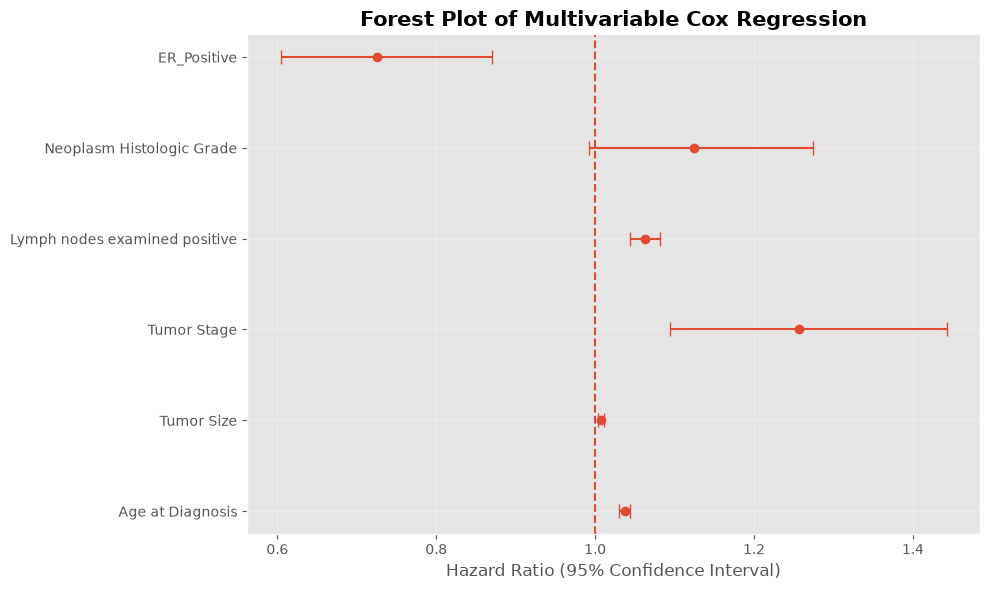

In [21]:
# ============================================================
# Forest Plot of Hazard Ratios
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(forest_df))

# Error bars
lower_error = forest_df["HR"] - forest_df["LowerCI"]
upper_error = forest_df["UpperCI"] - forest_df["HR"]

ax.errorbar(
    forest_df["HR"],
    y_pos,
    xerr=[lower_error, upper_error],
    fmt="o",
    capsize=5
)

# Reference line
ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1.5
)

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["Variable"])

ax.set_xlabel("Hazard Ratio (95% Confidence Interval)")
ax.set_title(
    "Forest Plot of Multivariable Cox Regression",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "figures" / "cox_forest_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()